| Step              | Purpose                        |
| ----------------- | ------------------------------ |
| Data loading      | Reads stock prices             |
| Normalization     | Makes training stable          |
| Sequence creation | Gives memory to RNN            |
| RNN layer         | Learns past trends             |
| Dense layer       | Outputs next price             |
| Plot              | Compares prediction vs reality |


X_train shape: (8, 5, 1)
X_test shape: (2, 5, 1)


C:\Users\Dev\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.3848 - val_loss: 0.5586
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.2477 - val_loss: 0.3039
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1415 - val_loss: 0.1282
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0665 - val_loss: 0.0297
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0225 - val_loss: 0.0011
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0075 - val_loss: 0.0262
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0157 - val_loss: 0.0775
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0361 - val_loss: 0.1247
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0559 - val_loss: 0.1486
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0661 - val_loss: 0.1461
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0652 - val_loss: 0.1237
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0558 - val_loss: 0.0913
Epo

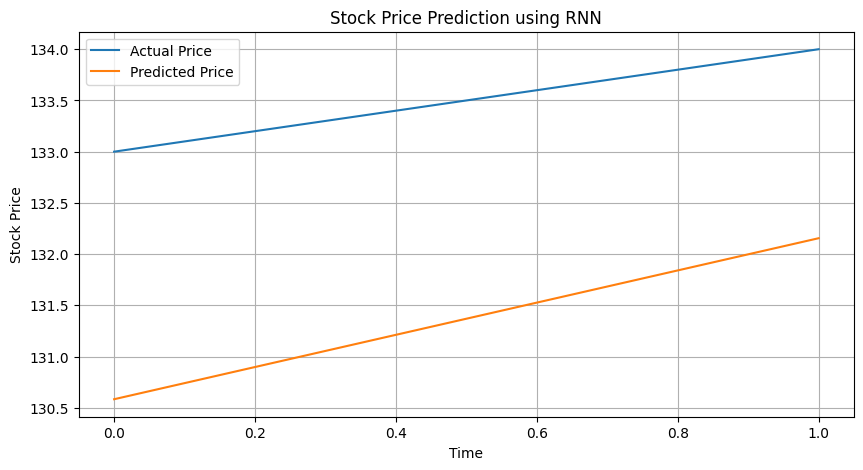

In [1]:
# =====================================
# 1. Import Libraries
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


# =====================================
# 2. Load Dataset
# =====================================
data = pd.read_csv("stock_data.csv")
prices = data["Close"].values.reshape(-1, 1)


# =====================================
# 3. Normalize Data
# =====================================
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices)


# =====================================
# 4. Create Sequences (IMPORTANT)
# =====================================
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)


WINDOW_SIZE = 5
X, y = create_sequences(prices_scaled, WINDOW_SIZE)


# =====================================
# 5. Train-Test Split
# =====================================
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


# =====================================
# 6. FIX: Reshape for RNN (3D Input)
# =====================================
# RNN expects: (samples, time_steps, features)
X_train = X_train.reshape((X_train.shape[0], WINDOW_SIZE, 1))
X_test  = X_test.reshape((X_test.shape[0], WINDOW_SIZE, 1))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


# =====================================
# 7. Build RNN Model
# =====================================
model = Sequential()
model.add(SimpleRNN(
    units=50,
    activation="tanh",
    input_shape=(WINDOW_SIZE, 1)
))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()


# =====================================
# 8. Train Model
# =====================================
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)


# =====================================
# 9. Predict Prices
# =====================================
predictions = model.predict(X_test)

# Reverse scaling
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))


# =====================================
# 10. Plot Results
# =====================================
plt.figure(figsize=(10, 5))
plt.plot(actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title("Stock Price Prediction using RNN")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid()
plt.show()